## As the classified data has subsetted genes; for complete gene counts - classification column added to original counts based on cell barcodes and checked for T cell markers expression

In [1]:
import scanpy as sc
import anndata
import pandas as pd
from matplotlib import rcParams
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
adata_v2 = sc.read_h5ad('/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/Ding_lab/RNA/updated_batch/updated_batch_datasource_chemistry/nk_ding_eMLclassified_adata_batch_DataSource_Chemistry_classification_SourceType_v2.h5ad')

In [41]:
adata_v2

AnnData object with n_obs × n_vars = 11536 × 4000
    obs: 'X', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'Sample_ATAC', 'Cohort', 'Sample_type', 'Chemistry', 'cell_type.atac', 'cell_type.harmonized.cancer', 'Piece_ID_RNA', 'data.type.rna', 'Sample_RNA', 'Case_ID_RNA', 'S.Score', 'G2M.Score', 'Phase', 'Data.source', 'Batches', 'integrated_snn_res.2', 'cell_type_v8_allRNA2', 'cell_type_v8.0_Tcell', 'cell_type_v8.2_rna', 'integrated_snn_res.1', 'integrated_snn_res.1.5', 'cell_type_v8.5_rna', 'integrated_snn_res.1.3', 'cell_type_v8.5_multi', 'integrated_snn_res.2.5', 'cell_type_v8.6_rna', 'cell_type_v8.7_rna', 'Sample.source', 'Tissue.normal', 'Data.source_Chemistry', 'batch', 'celltype.l2', 'dataset_name', '_scvi_labels', '_scvi_batch', 'CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob', 'CD56brightBRFprob', 'CD56dimBRFprob', 'eML1BRFprob', 'eML2BRFprob', 'predictionsBBC', 'predictionsBRF', 'classification', 'Source', 'S

In [ ]:
# orginal NK cell data

In [6]:
ref_adata = "/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/Ding_lab/RNA/updated_batch/updated_batch_datasource_chemistry/classifier_files/fig4_reference_adata_train_posttotalvi.h5ad"
RNApath = f"/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/Ding_lab/RNA/updated_batch/updated_batch_datasource_chemistry/csv/data_classifier/rna_counts_CLEAN_nkcells_RNA.csv"
metapath =  f"/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/Ding_lab/RNA/updated_batch/updated_batch_datasource_chemistry/csv/data_classifier/meta_CLEAN_nkcells_RNA_DataSource_Chemistry.csv"
ADTpath = f"ADTcounts.csv"
umappath = "/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/Ding_lab/RNA/updated_batch/updated_batch_datasource_chemistry/csv/data_classifier/umap_coordinates_CLEAN_nkcells_RNA.csv"
batch = 'Data.source_Chemistry'

In [ ]:
adata = sc.read_csv(RNApath)
adata = adata.transpose()

# inspect the barcodes
print('RNA Indexes Before')
print(adata.obs.index)
# If there are X's
#adata.obs.index = adata.obs.index.str.replace('X', '') # note default value of regex changing in other versions, current default is True; if needed uncomment this
adata.obs.index = adata.obs.index.str.replace('\.', '-', regex = True)
print('RNA Indexes After')
print(adata.obs.index)
print()

meta = pd.read_csv(metapath, index_col = 0)
adata.obs = meta
print('Meta Indexes')
print(meta.index)
print()

ref = sc.read_h5ad(ref_adata)

# if no protein data:
# put matrix of zeros for protein expression (considered missing)
pro_exp = ref.obsm["protein_expression"]
data = np.zeros((adata.n_obs, pro_exp.shape[1]))
adata.obsm["protein_expression"] = pd.DataFrame(
        columns=pro_exp.columns, index=adata.obs_names, data=data
        )
print(adata.obsm["protein_expression"]) # visualize query
print(ref.obsm["protein_expression"]) # visualize ref
print(sum(adata.obsm["protein_expression"].columns == ref.obsm["protein_expression"].columns)) # confirm protein features are the same
# below for all patient samples regardless of whether they have ADT data
print(sum(meta.index == adata.obs.index))
print(adata.obs.index.equals(meta.index))
adata.obs['batch'] = adata.obs[batch]

adata.raw = adata

adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata.raw = adata # move normalized data to adata raw

adata.obs["celltype.l2"] = "Unknown"

# reorganize query proteins, missing proteins become all 0
for p in ref.obsm["protein_expression"].columns:
    if p not in adata.obsm["protein_expression"].columns:
        adata.obsm["protein_expression"][p] = 0.0

# ensure columns are in same order
adata.obsm["protein_expression"] = adata.obsm["protein_expression"].loc[
    :, ref.obsm["protein_expression"].columns]

ref.obs["dataset_name"] = "Reference"
adata.obs["dataset_name"] = "Query"

In [ ]:
umap = pd.read_csv(umappath, index_col = 0)
adata = adata[umap.index] 
umap = umap.to_numpy() # convert to array
adata.obsm["X_umap"] = umap

In [7]:
#adata.write('/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/Ding_lab/RNA/updated_batch/updated_batch_datasource_chemistry/nk_ding_prepped_batch_Datasource_chemistry.h5ad')

In [24]:
adata = sc.read_h5ad('/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/Ding_lab/RNA/updated_batch/updated_batch_datasource_chemistry/nk_ding_prepped_batch_Datasource_chemistry.h5ad')

In [26]:
common_cells = adata_v2.obs_names.intersection(adata.obs_names)

In [27]:
adata.obs.loc[common_cells, 'classification'] = adata_v2.obs.loc[common_cells, 'classification']

In [28]:
adata

AnnData object with n_obs × n_vars = 11536 × 36601
    obs: 'X', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'Sample_ATAC', 'Cancer', 'Sample_type', 'Chemistry', 'cell_type.atac', 'cell_type.harmonized.cancer', 'Piece_ID_RNA', 'data.type.rna', 'Sample_RNA', 'Case_ID_RNA', 'S.Score', 'G2M.Score', 'Phase', 'Data.source', 'Batches', 'integrated_snn_res.2', 'cell_type_v8_allRNA2', 'cell_type_v8.0_Tcell', 'cell_type_v8.2_rna', 'integrated_snn_res.1', 'integrated_snn_res.1.5', 'cell_type_v8.5_rna', 'integrated_snn_res.1.3', 'cell_type_v8.5_multi', 'integrated_snn_res.2.5', 'cell_type_v8.6_rna', 'cell_type_v8.7_rna', 'Sample.source', 'Tissue.normal', 'Data.source_Chemistry', 'batch', 'celltype.l2', 'dataset_name', 'classification'
    uns: 'log1p'
    obsm: 'protein_expression'
    layers: 'counts'

*Addition of Source_type_v2 to the original data*

In [29]:
adata.obs.loc[common_cells, 'Source_type_v2'] = adata_v2.obs.loc[common_cells, 'Source_type_v2']

Missing genes: []


/Users/vedanagapriyavangala/Library/Python/3.9/lib/python/site-packages/scanpy/preprocessing/_scale.py:316: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


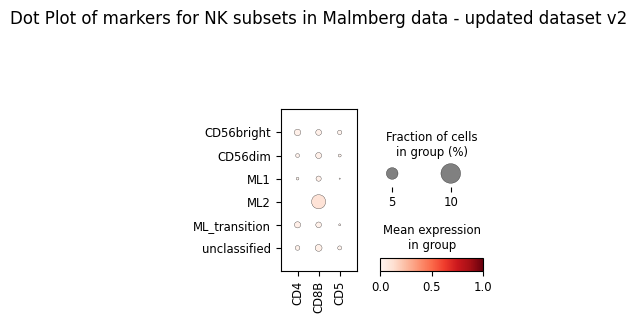

In [30]:
genes = ["CD4", "CD8B","CD5" ]

# Check for missing genes
missing_genes = [gene for gene in genes if gene not in adata.var_names]
print("Missing genes:", missing_genes)

# Filter valid genes (those present in adata.var_names)
valid_genes = [gene for gene in genes if gene in adata.var_names]

# Check if there are any valid genes to plot
if not valid_genes:
    raise ValueError("No valid genes to plot.")

# Subset the adata object to include only the valid genes
adata_valid = adata[:, valid_genes]

# Scale the expression data for the valid genes (standardizing by z-score)
sc.pp.scale(adata_valid, zero_center=True, max_value=None)

# Generate a combined dot plot for all categories of 'classification'
sc.pl.dotplot(adata_valid, var_names=valid_genes, groupby='classification', 
              cmap='Reds', title='Dot Plot of markers for NK subsets in Malmberg data - updated dataset v2', vmax=1)

In [38]:
umap = pd.read_csv(umappath, index_col = 0)
adata = adata[umap.index] 
umap = umap.to_numpy() # convert to array
adata.obsm["X_umap"] = umap

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_83257/3300520915.py:4: ImplicitModificationWarning: Setting element `.obsm['X_umap']` of view, initializing view as actual.
  adata.obsm["X_umap"] = umap


In [33]:
# Convert the expression matrix to a DataFrame (dense if sparse)
if hasattr(adata_valid.X, "toarray"):  # If sparse matrix
    expr_matrix = adata_valid.X.toarray()
else:
    expr_matrix = adata_valid.X

expr_df = pd.DataFrame(expr_matrix, columns=valid_genes, index=adata_valid.obs_names)

# Binary expression: 1 if expressed (>0), 0 if not
expr_binary = (expr_df > 0).astype(int)

# Calculate % of cells expressing each gene per 'classification'
percent_expr = expr_binary.groupby(adata_valid.obs['classification']).mean() * 100

print("Percentage of cells expressing each gene per classification:\n")
print(percent_expr)

Percentage of cells expressing each gene per classification:

                     CD4      CD8B       CD5
classification                              
CD56bright      2.380952  1.966874  1.345756
CD56dim         1.140341  2.054872  0.801626
ML1             0.729927  1.703163  0.243309
ML2             0.000000  6.451613  0.000000
ML_transition   2.147971  1.909308  0.477327
unclassified    1.463415  2.439024  1.219512


/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_83257/2991829299.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  percent_expr = expr_binary.groupby(adata_valid.obs['classification']).mean() * 100
